In [42]:
import pandas as pd
import  numpy as np

In [73]:
data = pd.read_csv("powerplant_data.csv")
data.head()
# AT >> Temperature
# V >> Vaccum
# AP >> Pressure
# RH >> Humidity

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [74]:
data.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [75]:
x = data.drop("PE", axis = 1)
y = data["PE"]

In [76]:
# spliting the data
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.2)

In [77]:
# scalering the data 
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train_s = sc.fit_transform(x_train)
x_test_s = sc.transform(x_test)

In [78]:
# to convert the data into tensors
import torch
import torch.nn as nn

x_train_tensor = torch.tensor(x_train_s, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1) # .values is used becuase y_train is still a pandas series. we didnt used it for scaled values becuase after scaling they automatically converted into numpy array
# and .view(-1,1), here we first select rows and then columns.. basically we convert horizontal data of 1d array into (n,1) to correctly fed to the model
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)
x_test_tensor = torch.tensor(x_test_s, dtype=torch.float32)

In [79]:
# Now to convert it into Tensor Dataset and Dataloader
from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

# to build the DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# DEEP LEARNING

In [81]:
# DEFINE OUR ANN MODEL

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__() # here we call the constructor of the base class to inintialize the model
        self.model = nn.Sequential(
        #1st hidden layer
        nn.Linear(x_train.shape[1], 6),
        nn.ReLU(),
        # 2nd hidden layer
        nn.Linear(6, 6),
        nn.ReLU(),
        # output layer
        nn.Linear(6,1),
    )
    def forward(self, x):
        return self.model(x)

In [82]:
# defining the loss and optimizer
import torch.optim as optim
model = ANN()

crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [83]:
# Training of Our ANN Model
epocs = 100
best_val_loss = float("inf")
train_loss =[]
val_loss = []
for epoc in range(epocs):
    model.train()
    running_loss = 0.0 # we store the total training loss for one epoch
    for xb, yb in train_loader:
        # xb >> features of one batch
        # yb >> labels of one batch
        optimizer.zero_grad() # to compute the new gradient everytime instead of commulating it 
        outputs = model(xb) # forward propagation commute the outputs for this batch
        loss = crietrion(outputs, yb) # compute the loss
        loss.backward() # backpropagation compute the gradients
        optimizer.step() # parameters update
        running_loss += loss.item() # >> .item() to convert the tensor value to the py float value

    epoc_train_loss = running_loss/len(train_loader)
    train_loss.append(epoc_train_loss)

## validation of data
    running_val_loss = 0.0
    with torch.no_grad(): # no gradient computation
        model.eval()
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss.item()

        epoc_val_loss = running_val_loss/ len(test_loader)
        val_loss.append(epoc_val_loss)

    print(f"epoch{epoc+1} / {epocs} >>> training_loss = {epoc_val_loss} and validation_loss = {epoc_train_loss}")
    if epoc_val_loss< best_val_loss:
        best_val_loss = epoc_val_loss
        torch.save(model.state_dict(), "best_model.pt") # we used to store these vlaues in pt or .pth. it stores only learnable pearatermeters for example b and w
        

epoch1 / 100 >>> training_loss = 205567.15364583334 and validation_loss = 206232.07376302083
epoch2 / 100 >>> training_loss = 200166.4625 and validation_loss = 203884.6900390625
epoch3 / 100 >>> training_loss = 176310.23072916668 and validation_loss = 190210.90598958332
epoch4 / 100 >>> training_loss = 134228.212109375 and validation_loss = 156544.07275390625
epoch5 / 100 >>> training_loss = 86787.42291666666 and validation_loss = 110242.26643880208
epoch6 / 100 >>> training_loss = 49757.32571614583 and validation_loss = 67033.04147135417
epoch7 / 100 >>> training_loss = 27367.121223958333 and validation_loss = 37381.250236002605
epoch8 / 100 >>> training_loss = 16359.0478515625 and validation_loss = 21179.99949544271
epoch9 / 100 >>> training_loss = 11796.1513671875 and validation_loss = 13910.420920817058
epoch10 / 100 >>> training_loss = 9391.18993326823 and validation_loss = 10747.204958089193
epoch11 / 100 >>> training_loss = 7464.640616861979 and validation_loss = 8643.6840352376

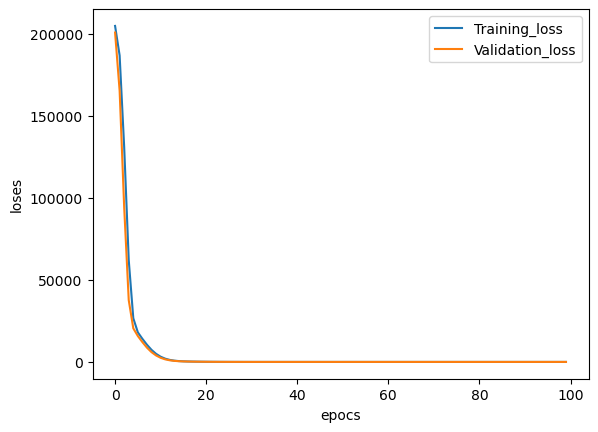

In [72]:
import matplotlib.pyplot as plt
loss_df = pd.DataFrame({"Training_loss": train_loss,
"validation_loss": val_loss})
plt.plot(loss_df["Training_loss"], label = "Training_loss")
plt.plot(loss_df["validation_loss"], label = "Validation_loss")
plt.xlabel("epocs")
plt.ylabel("loses")
plt.legend()

In [85]:
# retrieving the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [88]:
# Evaluation of model
model.eval()
with torch.no_grad():
    train_preds = model(x_train_tensor)
    test_preds = model(x_test_tensor)

    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Test MSE:", test_mse_loss.item())

Training MSE: 20.582170486450195
Test MSE: 18.899168014526367


In [90]:
from sklearn.metrics import r2_score
print("r2 Score", r2_score(y_test, test_preds))

r2 Score 0.9339522920013036


In [97]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns = ["Predicted Values"])
Actual_df = pd.DataFrame(y_test.values, columns = ["Actual Values"])

pd.concat([Actual_df, predicted_df], axis = 1)

,Actual Values,Predicted Values
0,433.27,435.159119
1,438.16,437.061920
2,458.42,461.497070
3,480.82,476.569763
4,441.41,435.344055
...,...,...
1909,456.70,451.454651
1910,438.04,431.661499
1911,467.80,467.549652
1912,437.14,431.124756
